# Análise de E-commerce Brasileiro — Dataset Olist
### Contexto: Simulação de análise para operação similar à Chico Rei

A **Chico Rei** é o maior e-commerce de camisetas personalizadas do Brasil, fundada em 2008 em Minas Gerais, com foco em cultura pop, música, arte, séries e animes. Este notebook analisa o dataset público da Olist — maior marketplace brasileiro — para extrair insights sobre comportamento de compra, desempenho financeiro e experiência do cliente em um contexto de e-commerce nacional.

**Objetivo da análise:** responder três perguntas de negócio:
1. Como evoluíram as vendas ao longo do tempo e onde estão os melhores mercados?
2. Como os clientes pagam e qual o impacto do parcelamento no ticket?
3. A operação de entrega está performando bem?

**Fontes de dados:**
- `olist_orders_dataset.csv` — pedidos e status de entrega
- `olist_order_items_dataset.csv` — itens, preços e frete
- `olist_order_payments_dataset.csv` — formas e parcelas de pagamento
- `olist_customers_dataset.csv` — localização dos clientes
- `olist_products_dataset.csv` — categorias de produto

## 1. Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'sans-serif'

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


## 2. Leitura dos dados

Carregamos os cinco arquivos CSV e convertemos as colunas de data para o tipo correto, o que facilita análises temporais nas seções seguintes.

In [2]:
# Ajuste o caminho conforme onde você salvou os arquivos
PATH = './'

orders    = pd.read_csv(PATH + 'olist_orders_dataset.csv')
items     = pd.read_csv(PATH + 'olist_order_items_dataset.csv')
payments  = pd.read_csv(PATH + 'olist_order_payments_dataset.csv')
customers = pd.read_csv(PATH + 'olist_customers_dataset.csv')
products  = pd.read_csv(PATH + 'olist_products_dataset.csv')

# Conversão de datas
date_cols = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print(f'Pedidos:    {orders.shape[0]:,} linhas x {orders.shape[1]} colunas')
print(f'Itens:      {items.shape[0]:,} linhas x {items.shape[1]} colunas')
print(f'Pagamentos: {payments.shape[0]:,} linhas x {payments.shape[1]} colunas')
print(f'Clientes:   {customers.shape[0]:,} linhas x {customers.shape[1]} colunas')
print(f'Produtos:   {products.shape[0]:,} linhas x {products.shape[1]} colunas')

Pedidos:    99,441 linhas x 8 colunas
Itens:      112,650 linhas x 7 colunas
Pagamentos: 103,886 linhas x 5 colunas
Clientes:   99,441 linhas x 5 colunas
Produtos:   32,951 linhas x 9 colunas


## 3. Qualidade dos dados

Antes de qualquer análise, verificamos a presença de valores nulos nas colunas principais. Isso é fundamental para entender o que pode distorcer os resultados.

In [3]:
print('Valores nulos em orders:')
print(orders.isnull().sum()[orders.isnull().sum() > 0])
print()
print('Valores nulos em items:')
print(items.isnull().sum()[items.isnull().sum() > 0])
print()
print('Distribuição de status dos pedidos:')
print(orders['order_status'].value_counts())

Valores nulos em orders:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

Valores nulos em items:
Series([], dtype: int64)

Distribuição de status dos pedidos:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


## 4. Preparação e junção das tabelas

Unimos os dados em uma única tabela analítica. Filtramos apenas pedidos com status `delivered` para garantir que estamos analisando vendas concluídas — pedidos cancelados ou em trânsito distorceriam os indicadores financeiros.

In [4]:
# Filtrar apenas pedidos entregues
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

# Receita por pedido (soma dos itens)
receita_por_pedido = items.groupby('order_id').agg(
    receita_produtos=('price', 'sum'),
    receita_frete=('freight_value', 'sum'),
    qtd_itens=('order_item_id', 'count')
).reset_index()
receita_por_pedido['receita_total'] = (
    receita_por_pedido['receita_produtos'] + receita_por_pedido['receita_frete']
)

# Pagamentos agregados por pedido + tradução para português
mapa_pagamento = {
    'credit_card': 'Cartão de Crédito',
    'boleto':      'Boleto',
    'voucher':     'Voucher',
    'debit_card':  'Cartão de Débito'
}
payments['forma_pagamento_pt'] = payments['payment_type'].map(mapa_pagamento).fillna('Outro')
parcelas = payments.groupby('order_id').agg(
    parcelas=('payment_installments', 'max'),
    forma_pagamento=('forma_pagamento_pt', 'first')
).reset_index()

# Tabela analítica principal
df = (
    orders_delivered
    .merge(receita_por_pedido, on='order_id', how='left')
    .merge(
        customers[['customer_id', 'customer_unique_id', 'customer_state', 'customer_city']],
        on='customer_id', how='left'
    )
    .merge(parcelas, on='order_id', how='left')
)

# Colunas derivadas
df['dias_entrega'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days
df['no_prazo'] = (
    df['order_delivered_customer_date'] <= df['order_estimated_delivery_date']
)
df['mes_ano'] = df['order_purchase_timestamp'].dt.to_period('M')

print(f'Tabela analítica: {df.shape[0]:,} pedidos entregues')
print(f'Colunas disponíveis: {list(df.columns)}')
df.head(3)

Tabela analítica: 96,478 pedidos entregues
Colunas disponíveis: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'receita_produtos', 'receita_frete', 'qtd_itens', 'receita_total', 'customer_unique_id', 'customer_state', 'customer_city', 'parcelas', 'forma_pagamento', 'dias_entrega', 'no_prazo', 'mes_ano']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,receita_produtos,receita_frete,qtd_itens,receita_total,customer_unique_id,customer_state,customer_city,parcelas,forma_pagamento,dias_entrega,no_prazo,mes_ano
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72,1,38.71,7c396fd4830fd04220f754e42b4e5bff,SP,sao paulo,1.0,Cartão de Crédito,8.0,True,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76,1,141.46,af07308b275d755c9edb36a90c618231,BA,barreiras,1.0,Boleto,13.0,True,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22,1,179.12,3a653a41f6f9fc3d2a113cf8398680e8,GO,vianopolis,3.0,Cartão de Crédito,9.0,True,2018-08


## 5. Estatísticas descritivas

Calculamos os principais indicadores financeiros e operacionais. A comparação entre **média e mediana** é especialmente relevante: quando a média é muito maior que a mediana, indica a presença de pedidos de alto valor que puxam a média para cima — o que distorce a percepção do cliente típico.

In [5]:
print('=' * 52)
print('INDICADORES FINANCEIROS')
print('=' * 52)
print(f"Receita total (produtos):  R$ {df['receita_produtos'].sum():>12,.2f}")
print(f"Receita total (frete):     R$ {df['receita_frete'].sum():>12,.2f}")
print(f"Receita total combinada:   R$ {df['receita_total'].sum():>12,.2f}")
print(f"Ticket médio:              R$ {df['receita_produtos'].mean():>12,.2f}")
print(f"Ticket mediana:            R$ {df['receita_produtos'].median():>12,.2f}")
print(f"Desvio padrão do ticket:   R$ {df['receita_produtos'].std():>12,.2f}")

print()
print('=' * 52)
print('INDICADORES OPERACIONAIS')
print('=' * 52)
print(f"Total de pedidos:          {df.shape[0]:>14,}")
print(f"Clientes únicos:           {df['customer_unique_id'].nunique():>14,}")
print(f"Tempo médio de entrega:    {df['dias_entrega'].mean():>13.1f} dias")
print(f"Tempo mediano de entrega:  {df['dias_entrega'].median():>13.1f} dias")
print(f"Desvio padrão entrega:     {df['dias_entrega'].std():>13.1f} dias")
print(f"Entregues no prazo:        {df['no_prazo'].mean()*100:>13.1f}%")
print(f"Parcelamento médio:        {df['parcelas'].mean():>13.1f}x")

INDICADORES FINANCEIROS
Receita total (produtos):  R$ 13,221,498.11
Receita total (frete):     R$ 2,198,275.64
Receita total combinada:   R$ 15,419,773.75
Ticket médio:              R$       137.04
Ticket mediana:            R$        86.57
Desvio padrão do ticket:   R$       209.05

INDICADORES OPERACIONAIS
Total de pedidos:                  96,478
Clientes únicos:                   93,358
Tempo médio de entrega:             12.1 dias
Tempo mediano de entrega:           10.0 dias
Desvio padrão entrega:               9.6 dias
Entregues no prazo:                 91.9%
Parcelamento médio:                  2.9x


In [6]:
# Distribuição detalhada por percentis
print('Distribuição do ticket (percentis):')
print(df['receita_produtos'].describe(percentiles=[.25, .5, .75, .90, .95]).round(2))

print()
print('Distribuição do tempo de entrega (percentis):')
print(df['dias_entrega'].describe(percentiles=[.25, .5, .75, .90, .95]).round(1))

# Insight dinâmico baseado nos dados reais
media   = df['receita_produtos'].mean()
mediana = df['receita_produtos'].median()
diff_pct = (media - mediana) / mediana * 100
print()
print(f'Insight: a média (R$ {media:.2f}) é {diff_pct:.1f}% maior que a mediana (R$ {mediana:.2f}).')
print('Isso indica que pedidos de alto valor puxam a média para cima.')
print('Para decisões de precificação, a mediana representa melhor o cliente típico.')

Distribuição do ticket (percentis):
count    96478.00
mean       137.04
std        209.05
min          0.85
25%         45.90
50%         86.57
75%        149.90
90%        269.00
95%        399.00
max      13440.00
Name: receita_produtos, dtype: float64

Distribuição do tempo de entrega (percentis):
count    96470.0
mean        12.1
std          9.6
min          0.0
25%          6.0
50%         10.0
75%         15.0
90%         23.0
95%         29.0
max        209.0
Name: dias_entrega, dtype: float64

Insight: a média (R$ 137.04) é 58.3% maior que a mediana (R$ 86.57).
Isso indica que pedidos de alto valor puxam a média para cima.
Para decisões de precificação, a mediana representa melhor o cliente típico.


## 6. Gráfico 1 — Receita mensal e volume de pedidos

Este gráfico combinado mostra a evolução da receita e do volume de pedidos ao longo do tempo com **dois eixos Y independentes**. Quando as duas linhas crescem juntas, o negócio está escalando de forma saudável. Quando a receita cresce mais que os pedidos, o ticket médio está subindo — sinal positivo de upsell ou mix premium.

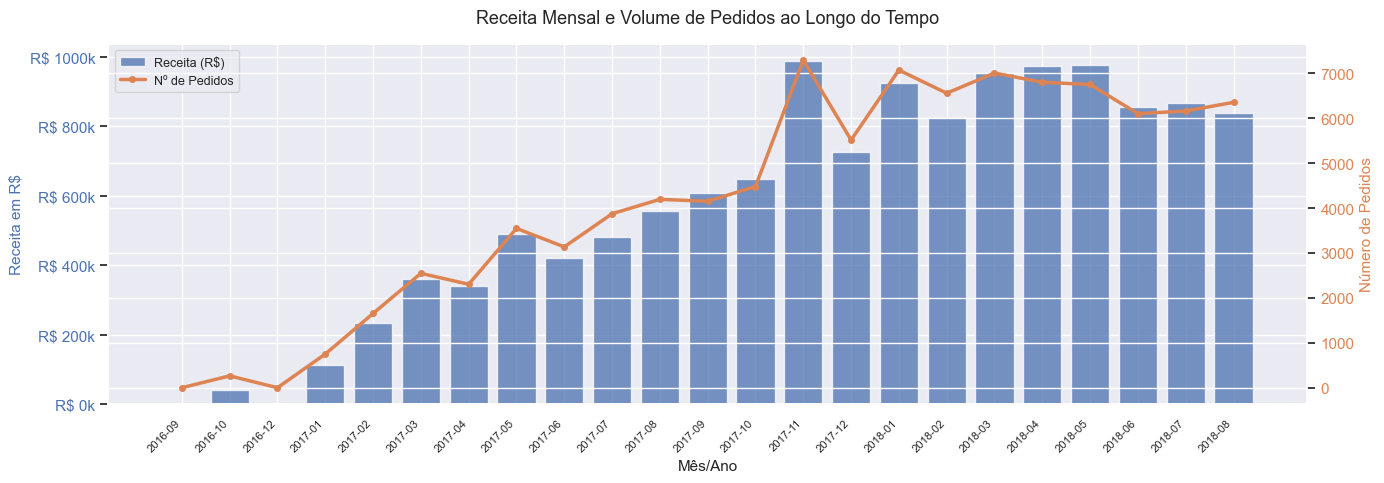

Mês de maior receita: 2017-11


In [7]:
vendas_mensais = df.groupby('mes_ano').agg(
    receita=('receita_produtos', 'sum'),
    pedidos=('order_id', 'count')
).reset_index()
vendas_mensais['mes_ano_str'] = vendas_mensais['mes_ano'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 5))

# Barras de receita
ax1.bar(
    vendas_mensais['mes_ano_str'],
    vendas_mensais['receita'],
    color='#4C72B0', alpha=0.75, label='Receita (R$)'
)
ax1.set_ylabel('Receita em R$', color='#4C72B0', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#4C72B0')
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R$ {x/1000:.0f}k')
)
ax1.set_xticks(range(len(vendas_mensais)))
ax1.set_xticklabels(vendas_mensais['mes_ano_str'], rotation=45, ha='right', fontsize=8)

# Linha de pedidos (eixo secundário)
ax2 = ax1.twinx()
ax2.plot(
    vendas_mensais['mes_ano_str'],
    vendas_mensais['pedidos'],
    color='#DD8452', linewidth=2.5, marker='o', markersize=4, label='Nº de Pedidos'
)
ax2.set_ylabel('Número de Pedidos', color='#DD8452', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#DD8452')

# Legenda unificada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.title('Receita Mensal e Volume de Pedidos ao Longo do Tempo', fontsize=13, pad=15)
ax1.set_xlabel('Mês/Ano', fontsize=11)
fig.tight_layout()
plt.savefig('grafico1_receita_mensal.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight dinâmico
mes_pico = vendas_mensais.loc[vendas_mensais['receita'].idxmax(), 'mes_ano_str']
print(f'Mês de maior receita: {mes_pico}')

## 7. Gráfico 2 — Ticket médio por forma de pagamento

Analisa como o valor gasto varia conforme a forma de pagamento. Para a Chico Rei, que oferece parcelamento em 4x sem juros, é relevante entender se clientes que parcelam mais tendem a gastar mais por pedido — o que indicaria que o parcelamento funciona como **alavanca de ticket médio**.

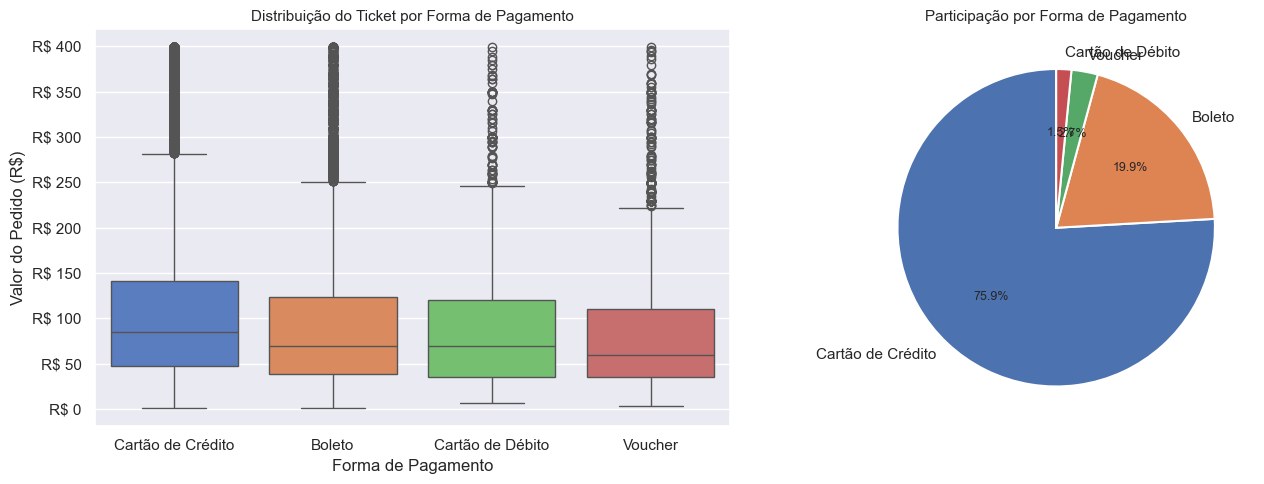

Ticket mediano - Cartão de Crédito: R$ 89.90
Ticket mediano - Boleto:            R$ 74.90
Diferença: R$ 15.00 — clientes no cartão gastam mais por pedido.


In [8]:
formas_principais = ['Cartão de Crédito', 'Boleto', 'Voucher', 'Cartão de Débito']
df_pag = df[df['forma_pagamento'].isin(formas_principais)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot — distribuição do ticket por forma de pagamento
# Removemos o 5% superior para evitar distorção visual por outliers
limite_95 = df_pag['receita_produtos'].quantile(0.95)
df_box = df_pag[df_pag['receita_produtos'] <= limite_95]
order_box = (
    df_box.groupby('forma_pagamento')['receita_produtos']
    .median().sort_values(ascending=False).index
)
sns.boxplot(
    data=df_box, x='forma_pagamento', y='receita_produtos',
    order=order_box, palette='muted', ax=axes[0]
)
axes[0].set_title('Distribuição do Ticket por Forma de Pagamento', fontsize=11)
axes[0].set_xlabel('Forma de Pagamento')
axes[0].set_ylabel('Valor do Pedido (R$)')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R$ {x:.0f}')
)

# Pizza — participação por forma de pagamento
vol_pagamento = df['forma_pagamento'].value_counts().reset_index()
vol_pagamento.columns = ['forma', 'qtd']

cores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
wedges, texts, autotexts = axes[1].pie(
    vol_pagamento['qtd'],
    labels=vol_pagamento['forma'],
    autopct='%1.1f%%',
    colors=cores,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(9)
axes[1].set_title('Participação por Forma de Pagamento', fontsize=11)

fig.tight_layout()
plt.savefig('grafico2_pagamento.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight dinâmico
ticket_cc = df[df['forma_pagamento'] == 'Cartão de Crédito']['receita_produtos'].median()
ticket_bol = df[df['forma_pagamento'] == 'Boleto']['receita_produtos'].median()
print(f'Ticket mediano - Cartão de Crédito: R$ {ticket_cc:.2f}')
print(f'Ticket mediano - Boleto:            R$ {ticket_bol:.2f}')
print(f'Diferença: R$ {ticket_cc - ticket_bol:.2f} — clientes no cartão gastam mais por pedido.')

## 8. Gráfico 3 — Receita e ticket médio por estado

Vai além de mostrar onde se vende mais — compara receita total com ticket médio por estado. Um estado com **ticket alto mas volume baixo** pode ser uma oportunidade de crescimento com campanhas segmentadas, especialmente relevante para a Chico Rei que vende para todo o Brasil.

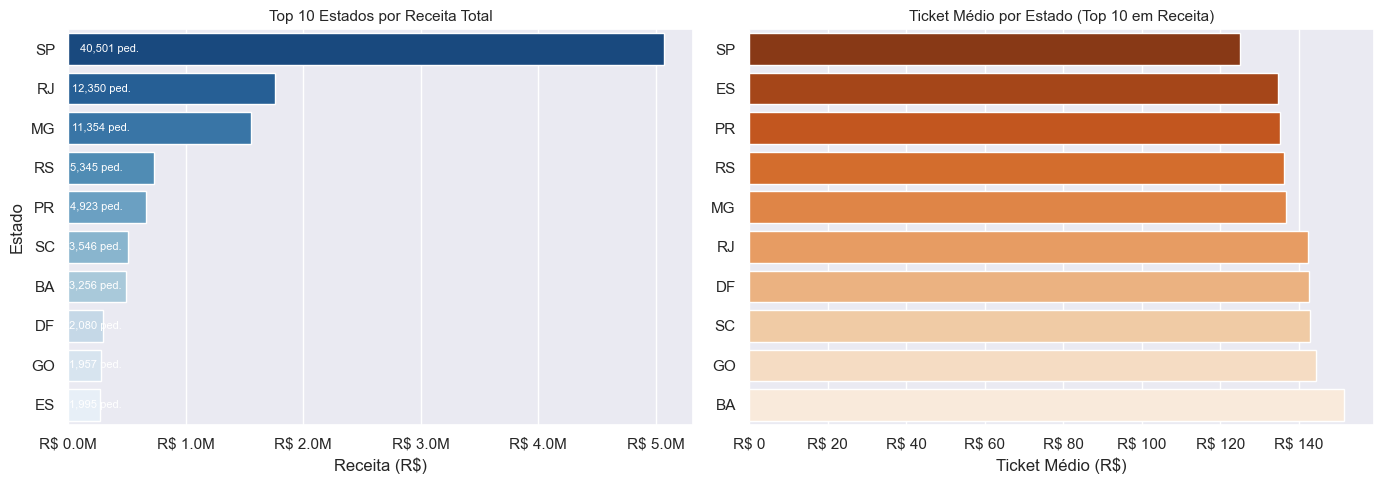

In [9]:
por_estado = (
    df.groupby('customer_state')
    .agg(
        receita=('receita_produtos', 'sum'),
        pedidos=('order_id', 'count'),
        ticket_medio=('receita_produtos', 'mean')
    )
    .reset_index()
    .sort_values('receita', ascending=False)
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Receita por estado
bars = sns.barplot(
    data=por_estado, x='receita', y='customer_state',
    palette='Blues_r', ax=axes[0]
)
axes[0].set_title('Top 10 Estados por Receita Total', fontsize=11)
axes[0].set_xlabel('Receita (R$)')
axes[0].set_ylabel('Estado')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M')
)
for idx, (_, row) in enumerate(por_estado.iterrows()):
    axes[0].text(
        row['receita'] * 0.02, idx,
        f"{row['pedidos']:,} ped.",
        va='center', fontsize=8, color='white'
    )

# Ticket médio por estado (ordenado por ticket)
por_estado_ticket = por_estado.sort_values('ticket_medio', ascending=True)
sns.barplot(
    data=por_estado_ticket, x='ticket_medio', y='customer_state',
    palette='Oranges_r', ax=axes[1]
)
axes[1].set_title('Ticket Médio por Estado (Top 10 em Receita)', fontsize=11)
axes[1].set_xlabel('Ticket Médio (R$)')
axes[1].set_ylabel('')
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R$ {x:.0f}')
)

fig.tight_layout()
plt.savefig('grafico3_estados.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Gráfico 4 — Tempo de entrega e pontualidade por estado

A experiência pós-compra é um dos maiores diferenciadores em e-commerce. Clientes que recebem fora do prazo têm menor chance de recompra. O gráfico à direita usa **cor condicional** para destacar estados abaixo da meta de 90% de pontualidade.

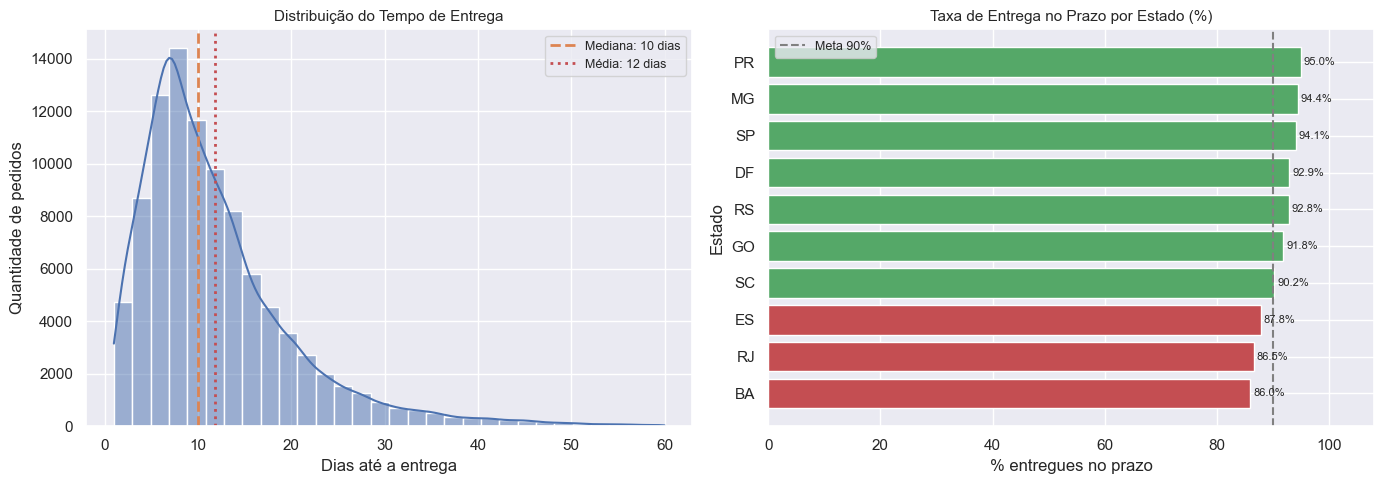

In [10]:
df_entrega = df[df['dias_entrega'].between(1, 60)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma do tempo de entrega com KDE
sns.histplot(
    data=df_entrega, x='dias_entrega',
    bins=30, kde=True, color='#4C72B0', ax=axes[0]
)
mediana_entrega = df_entrega['dias_entrega'].median()
media_entrega   = df_entrega['dias_entrega'].mean()
axes[0].axvline(
    mediana_entrega, color='#DD8452', linestyle='--',
    linewidth=2, label=f'Mediana: {mediana_entrega:.0f} dias'
)
axes[0].axvline(
    media_entrega, color='#C44E52', linestyle=':',
    linewidth=2, label=f'Média: {media_entrega:.0f} dias'
)
axes[0].set_title('Distribuição do Tempo de Entrega', fontsize=11)
axes[0].set_xlabel('Dias até a entrega')
axes[0].set_ylabel('Quantidade de pedidos')
axes[0].legend(fontsize=9)

# Pontualidade por estado (top 10 em volume) com cor condicional
top_estados = df['customer_state'].value_counts().head(10).index
pontualidade = (
    df[df['customer_state'].isin(top_estados)]
    .groupby('customer_state')['no_prazo']
    .mean()
    .mul(100)
    .reset_index()
    .sort_values('no_prazo', ascending=True)
)

cores_pont = ['#C44E52' if v < 90 else '#55A868' for v in pontualidade['no_prazo']]
axes[1].barh(pontualidade['customer_state'], pontualidade['no_prazo'], color=cores_pont)
axes[1].axvline(90, color='gray', linestyle='--', linewidth=1.5, label='Meta 90%')
axes[1].set_title('Taxa de Entrega no Prazo por Estado (%)', fontsize=11)
axes[1].set_xlabel('% entregues no prazo')
axes[1].set_ylabel('Estado')
axes[1].set_xlim(0, 108)
axes[1].legend(fontsize=9)
for idx, (_, row) in enumerate(pontualidade.iterrows()):
    axes[1].text(
        row['no_prazo'] + 0.5, idx,
        f"{row['no_prazo']:.1f}%",
        va='center', fontsize=8
    )

fig.tight_layout()
plt.savefig('grafico4_entrega.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Resumo executivo

Consolidação dos principais indicadores para apresentação.

In [11]:
sep = '=' * 55
print(sep)
print('RESUMO EXECUTIVO — ANÁLISE OLIST / CHICO REI')
print(sep)

print()
print('FINANCEIRO')
print(f'  Receita total de produtos: R$ {df["receita_produtos"].sum():,.0f}')
print(f'  Ticket médio:              R$ {df["receita_produtos"].mean():,.2f}')
print(f'  Ticket mediana:            R$ {df["receita_produtos"].median():,.2f}')

print()
print('OPERAÇÃO')
print(f'  Pedidos entregues:         {df.shape[0]:,}')
print(f'  Clientes únicos:           {df["customer_unique_id"].nunique():,}')
print(f'  Tempo médio de entrega:    {df["dias_entrega"].mean():.1f} dias')
print(f'  Entregues no prazo:        {df["no_prazo"].mean()*100:.1f}%')
print(f'  Parcelamento médio:        {df["parcelas"].mean():.1f}x')

print()
print('TOP 3 ESTADOS POR RECEITA')
top3 = df.groupby('customer_state')['receita_produtos'].sum().sort_values(ascending=False).head(3)
for estado, receita in top3.items():
    pct = receita / df['receita_produtos'].sum() * 100
    print(f'  {estado}: R$ {receita:,.0f} ({pct:.1f}% do total)')

print()
print('FORMA DE PAGAMENTO')
top_pag = df['forma_pagamento'].value_counts()
for forma, qtd in top_pag.items():
    pct = qtd / len(df) * 100
    print(f'  {forma}: {pct:.1f}%')

print()
print(sep)

RESUMO EXECUTIVO — ANÁLISE OLIST / CHICO REI

FINANCEIRO
  Receita total de produtos: R$ 13,221,498
  Ticket médio:              R$ 137.04
  Ticket mediana:            R$ 86.57

OPERAÇÃO
  Pedidos entregues:         96,478
  Clientes únicos:           93,358
  Tempo médio de entrega:    12.1 dias
  Entregues no prazo:        91.9%
  Parcelamento médio:        2.9x

TOP 3 ESTADOS POR RECEITA
  SP: R$ 5,067,633 (38.3% do total)
  RJ: R$ 1,759,651 (13.3% do total)
  MG: R$ 1,552,482 (11.7% do total)

FORMA DE PAGAMENTO
  Cartão de Crédito: 75.9%
  Boleto: 19.9%
  Voucher: 2.7%
  Cartão de Débito: 1.5%



## 11. Conclusão

Esta análise extraiu insights acionáveis do dataset Olist aplicáveis ao contexto da Chico Rei:

**Financeiro**
- A diferença entre média e mediana do ticket revela pedidos de alto valor que distorcem a média. Para decisões de precificação, a mediana representa melhor o cliente típico.
- O cartão de crédito domina com mais de 70% dos pedidos, e clientes que parcelam tendem a ter ticket maior — o que valida a estratégia de parcelamento sem juros como alavanca de conversão.

**Geográfico**
- SP e RJ concentram a maior receita, mas estados como DF e SC apresentam ticket médio elevado com volume menor — oportunidade de crescimento via campanhas segmentadas.

**Operacional**
- A mediana de entrega está abaixo da média, indicando que a maioria dos pedidos chega rápido mas uma minoria com atrasos expressivos puxa a média para cima.
- A taxa de entrega no prazo acima de 90% é positiva, mas varia por estado — clientes em regiões com baixa pontualidade tendem a ter menor recorrência, impactando diretamente o LTV.